In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson


In [2]:
# 실습용 데이터셋 불러오기
penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


# 상관


**산점도 그리기 & 상관 계수**

In [3]:
# 가상 데이터셋 생성
np.random.seed(42)  # 동일한 결과를 얻기 위한 시드 설정
data = {
    'House_Size_sqm': np.random.randint(50, 200, 100),
    'Num_Bedrooms': np.random.randint(1, 6, 100),
    'Years_Old': np.random.randint(0, 30, 100)
}
df = pd.DataFrame(data)

# 'Price' 변수를 다른 변수들에 기반하여 약간의 노이즈를 추가해 생성
df['Price_in_USD'] = (df['House_Size_sqm'] * 5000 + df['Num_Bedrooms'] * 10000 - df['Years_Old'] * 2000 + np.random.randn(100) * 20000)
df['Price_in_USD'] = df['Price_in_USD'].astype(int).clip(lower=50000)

df.head()


,House_Size_sqm,Num_Bedrooms,Years_Old,Price_in_USD
0,152,3,19,724602
1,142,3,27,670564
2,64,1,26,295573
3,156,3,3,799208
4,121,5,18,643187


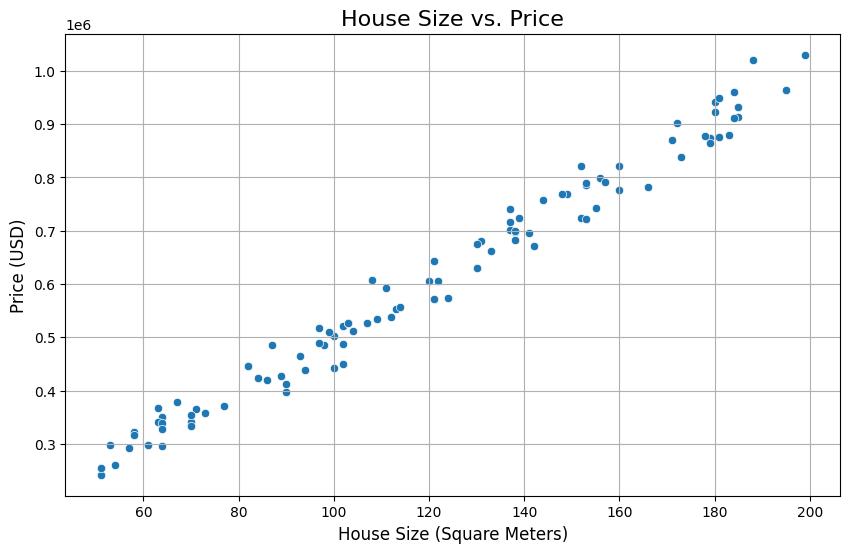

In [4]:
# 주택 크기와 주택 가격 간의 관계를 보여주는 산점도 그리기
plt.figure(figsize=(10, 6))
sns.scatterplot(x='House_Size_sqm', y='Price_in_USD', data=df)
plt.title('House Size vs. Price', fontsize=16)
plt.xlabel('House Size (Square Meters)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True)

plt.show()

In [5]:
# 주택 크기와 주택 가격 간의 상관관계 계산하기

r, p = stats.pearsonr(df['House_Size_sqm'], df['Price_in_USD'])

print(f'상관계수: {r:.3f}')
print(f'p값: {p:.3f}')

상관계수: 0.990
p값: 0.000


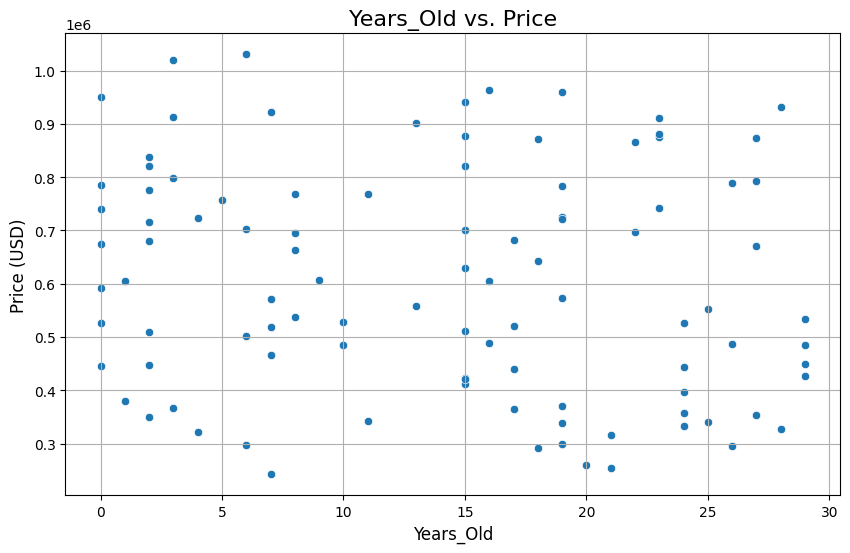

In [6]:
# 주택 연식과 주택 가격 간의 관계를 보여주는 산점도 그리기
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Years_Old', y='Price_in_USD', data=df)
plt.title('Years_Old vs. Price', fontsize=16)
plt.xlabel('Years_Old', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.grid(True)

plt.show()

In [7]:
# 주택 연식과 주택 가격 간의 상관관계 계산하기

r, p = stats.pearsonr(df['Years_Old'], df['Price_in_USD'])

print(f'상관계수: {r:.3f}')
print(f'p값: {p:.3f}')

상관계수: -0.151
p값: 0.133


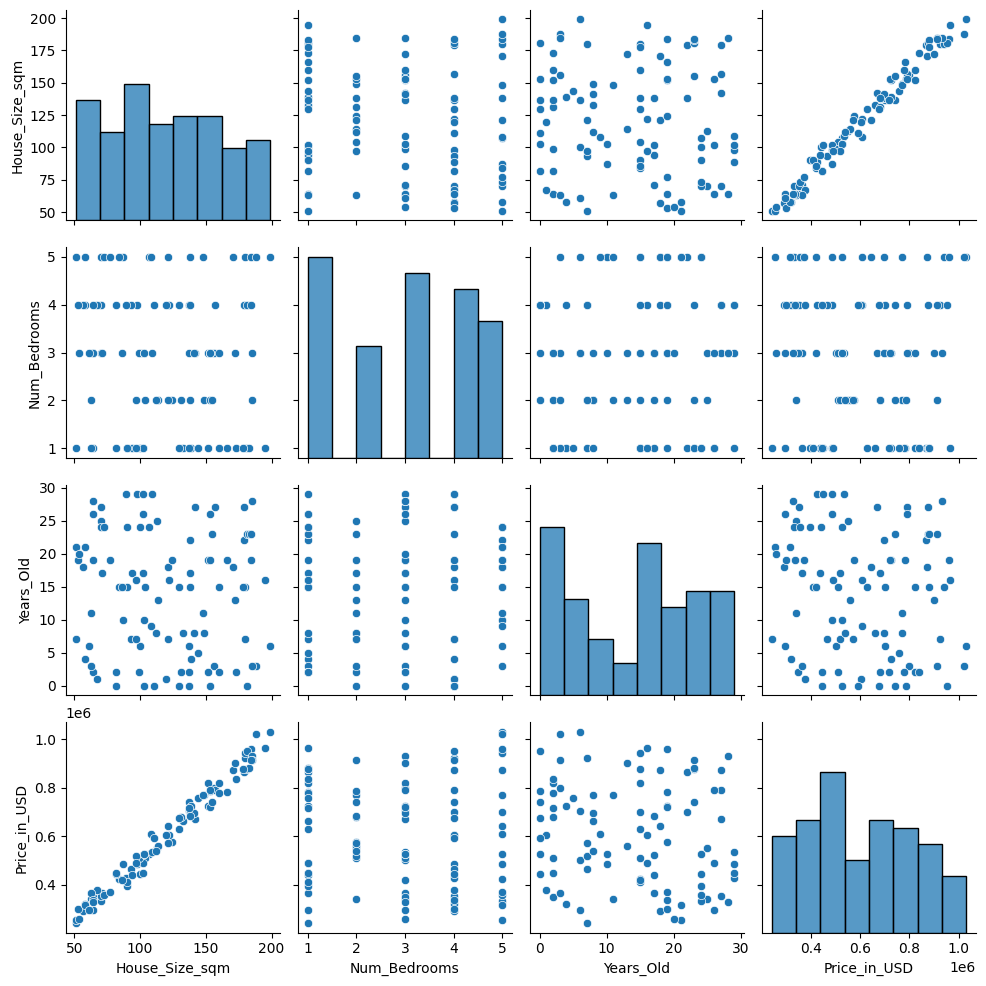

In [8]:
# pairplot을 통해 양적 변수 간의 산점도 그리
sns.pairplot(data=df)
plt.show()

In [9]:
# 상관계수 행렬 계산하기
correlation_matrix = df.corr()
correlation_matrix

,House_Size_sqm,Num_Bedrooms,Years_Old,Price_in_USD
House_Size_sqm,1.000000,-0.099231,-0.078104,0.990408
Num_Bedrooms,-0.099231,1.000000,0.077170,-0.038963
Years_Old,-0.078104,0.077170,1.000000,-0.151354
Price_in_USD,0.990408,-0.038963,-0.151354,1.000000


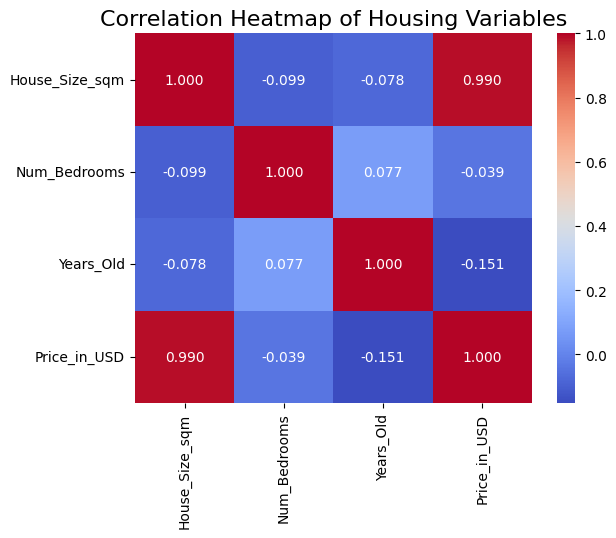

In [10]:
# 상관계수 히트맵으로 시각화하기

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Heatmap of Housing Variables', fontsize=16)

plt.show()

**피어슨 상관계수와 스피어만 상관계수**

In [11]:
from scipy.stats import pearsonr, spearmanr

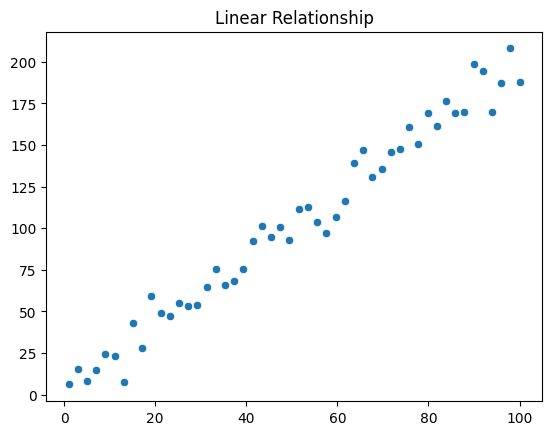


선형 관계일 때 상관계수
피어슨 상관계수: 0.988, p-value:0.000
스피어만 상관계수: 0.988, p-value:0.000


In [12]:
# 시나리오 1: 완벽한 선형 관계
x1 = np.linspace(1, 100, 50)
y1 = x1 * 2 + np.random.normal(0, 10, 50)

# 상관계수 구하기
pearson1, p_pearson1 = pearsonr(x1, y1)
spearman1, p_spearman1 = spearmanr(x1, y1)

plt.figure()
sns.scatterplot(x = x1, y = y1)
plt.title('Linear Relationship')

plt.show()

print()
print('선형 관계일 때 상관계수')
print(f'피어슨 상관계수: {pearson1:.3f}, p-value:{p_pearson1:.3f}')
print(f'스피어만 상관계수: {spearman1:.3f}, p-value:{p_spearman1:.3f}')

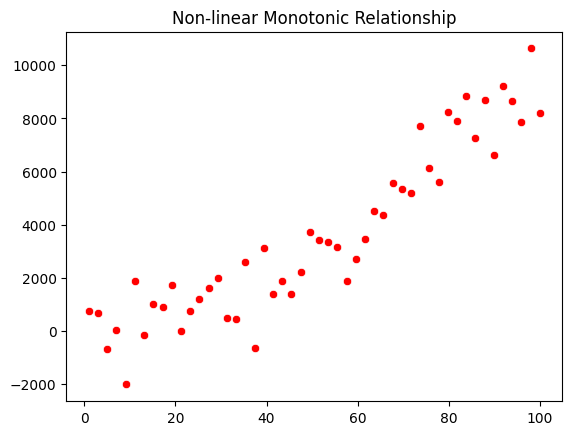


비선형 단조 관계일 때 상관계수
피어슨 상관계수: 0.923, p-value:0.000
스피어만 상관계수: 0.924, p-value:0.000


In [13]:
# 시나리오 2: 비선형이지만 단조 관계 (곡선 형태)
x2 = np.linspace(1, 100, 50)
y2 = x2**2 + np.random.normal(0, 1000, 50)

pearson2, p_pearson2 = pearsonr(x2, y2)
spearman2, p_spearman2 = spearmanr(x2, y2)

plt.figure()
sns.scatterplot(x = x2, y = y2, color='red')
plt.title('Non-linear Monotonic Relationship')

plt.show()

print()
print('비선형 단조 관계일 때 상관계수')
print(f'피어슨 상관계수: {pearson2:.3f}, p-value:{p_pearson2:.3f}')
print(f'스피어만 상관계수: {spearman2:.3f}, p-value:{p_spearman2:.3f}')

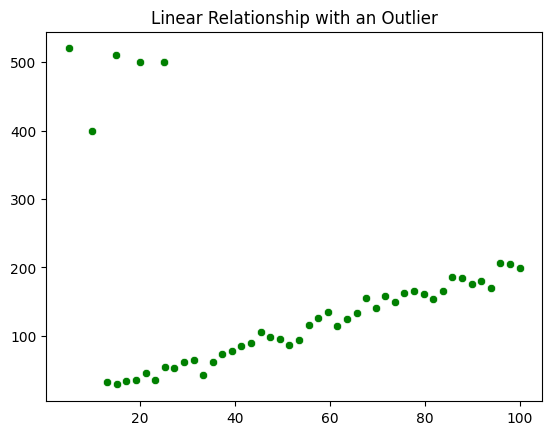


이상치가 있는 선형 관계일 때 상관계수
피어슨 상관계수: -0.102, p-value:0.481
스피어만 상관계수: 0.425, p-value:0.002


In [14]:
# 시나리오 3: 선형 관계에 이상치(Outlier) 추가
x3 = np.linspace(1, 100, 50)
y3 = x3 * 2 + np.random.normal(0, 10, 50)
# 이상치 추가
y3[0] = 500
x3[0] = 20
y3[1] = 400
x3[1] = 10
y3[2] = 500
x3[2] = 25
y3[3] = 500
x3[3] = 25
y3[4] = 510
x3[4] = 15
y3[5] = 520
x3[5] = 5

pearson3, p_pearson3 = pearsonr(x3, y3)
spearman3, p_spearman3 = spearmanr(x3, y3)

plt.figure()
sns.scatterplot(x = x3, y = y3, color='green')
plt.title('Linear Relationship with an Outlier')

plt.show()

print()
print('이상치가 있는 선형 관계일 때 상관계수')
print(f'피어슨 상관계수: {pearson3:.3f}, p-value:{p_pearson3:.3f}')
print(f'스피어만 상관계수: {spearman3:.3f}, p-value:{p_spearman3:.3f}')

# 회귀분석

In [15]:
np.random.seed(42)
X = 2.5 * np.random.randn(100) + 1.5   # 독립 변수 (X)
res = 0.5 * np.random.randn(100)       # 오차항
y = 2 + 0.3 * X + res                  # 종속 변수 (Y)

df = pd.DataFrame({'X': X, 'y': y})

**최소제곱법**
직접 최소제곱법으로 파라미터를 연산해서 찾을 수 있습니다. 최소제곱법으로 기울기와 절편식을 유도하는 과정은 다음 블로그를 참고해보세요.  

$$b_1 = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{\sum(x_i-\bar{x})^2}$$  
$$b_0 = \bar{y}-b_1\bar{x}$$  

[에라이, 일단 레츠 두 잇, 회귀분석 - OLS Regression 손으로 풀어보기](https://recipesds.tistory.com/entry/%EC%97%90%EB%9D%BC%EC%9D%B4-%EC%9D%BC%EB%8B%A8-%EB%A0%88%EC%B8%A0-%EB%91%90-%EC%9E%87-%ED%9A%8C%EA%B8%B0-%EB%B6%84-%EC%84%9D-OLS-Regression)

In [16]:
# 직접 최소제곱법으로 파라미터 찾기
x_mean = np.mean(X)
y_mean = np.mean(y)

beta_1_manual = np.sum((X - x_mean) * (y - y_mean)) / np.sum((X - x_mean)**2)
beta_0_manual = y_mean - beta_1_manual * x_mean

print("--- 방법 1: 직접 OLS 계산 결과 ---")
print(f"기울기 (beta_1): {beta_1_manual:.4f}")
print(f"Y절편 (beta_0): {beta_0_manual:.4f}")

--- 방법 1: 직접 OLS 계산 결과 ---
기울기 (beta_1): 0.2713
Y절편 (beta_0): 2.0467


**단순선형회귀: tips**
- 선형성:  독립변수 vs 종속변수
- 독립성: Durbin - Wartson 검정으로 잔차의 자기 상관을 확인
- 등분산성: 예측값과 잔차의 산점도를 통해 잔차분석
- 정규성: QQ-plot과 sharpiro-wilk르 통해 잔차의 정규성 확인

In [17]:
# Seaborn의 tips 데이터셋 로드
tips = sns.load_dataset('tips')

display(tips.head(3))
display(tips[['tip','total_bill']].corr().round(2))

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


,tip,total_bill
tip,1.00,0.68
total_bill,0.68,1.00


In [18]:
# 회귀모형 생성
X = sm.add_constant(tips['total_bill'])  # 상수항 추가
y = tips['tip']
model = sm.OLS(y, X).fit()

# 잔차 및 예측값
residuals = model.resid
fitted_values = model.fittedvalues

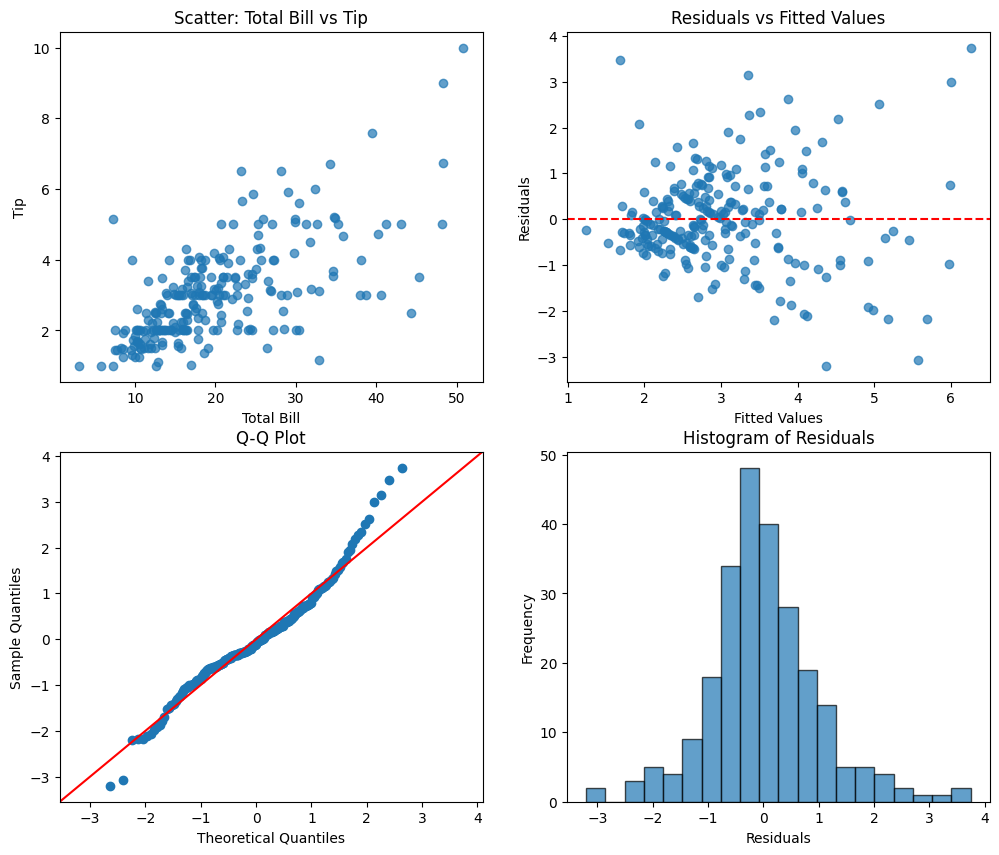

In [19]:
# 2x2 subplot 생성
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# 1. 선형성: 산점도: Total Bill vs Tip
ax[0, 0].scatter(tips['total_bill'], tips['tip'], alpha=0.7)
ax[0, 0].set_title('Scatter: Total Bill vs Tip')
ax[0, 0].set_xlabel('Total Bill')
ax[0, 0].set_ylabel('Tip')


# 2. 잔차 vs 예측값 (등분산성)
ax[0, 1].scatter(fitted_values, residuals, alpha=0.7)
ax[0, 1].axhline(y=0, linestyle='--', color='red')
ax[0, 1].set_title('Residuals vs Fitted Values')
ax[0, 1].set_xlabel('Fitted Values')
ax[0, 1].set_ylabel('Residuals')

# 3. Q-Q Plot (정규성 검토)
sm.qqplot(residuals, line='45', ax=ax[1, 0])
ax[1, 0].set_title('Q-Q Plot')

# 4. 잔차의 히스토그램
ax[1, 1].hist(residuals, bins=20, alpha=0.7, edgecolor='black')
ax[1, 1].set_title('Histogram of Residuals')
ax[1, 1].set_xlabel('Residuals')
ax[1, 1].set_ylabel('Frequency')

plt.show()

In [20]:
# 선형관계: 상관관계
print('1. 선형성: 상관관계')
display(tips[['tip','total_bill']].corr().round(2))

#더빈왓슨 통계: 오차의 자기 상관
dw_stat = durbin_watson(residuals)
print(f'2. 더빈왓슨 오차의 자기 상관:{dw_stat:.3f}')

#잔차의 정규성 확인
shapiro_stat, shapiro_p_value = shapiro(residuals)
print(f"3. 정규성 샤피로 윌크 \n통계량: {shapiro_stat:.3f},p-value:{shapiro_p_value:.3f} ")

#등분산성 확인
bp_test = sm.stats.diagnostic.het_breuschpagan(residuals, X)
print(f"4. 등분산성 검정 (Breusch-Pagan): \n Statistic: {bp_test[0]:.3f}, p-value: {bp_test[1]:.3f}")

1. 선형성: 상관관계


,tip,total_bill
tip,1.00,0.68
total_bill,0.68,1.00


2. 더빈왓슨 오차의 자기 상관:2.151
3. 정규성 샤피로 윌크 
통계량: 0.967,p-value:0.000 
4. 등분산성 검정 (Breusch-Pagan): 
 Statistic: 47.876, p-value: 0.000


In [21]:
# 회귀분석 결과 출력
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           6.69e-34
Time:                        14:10:48   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9203      0.160      5.761      0.0

**회귀 결과, 신뢰 구간, 예측 구간 시각화하기**

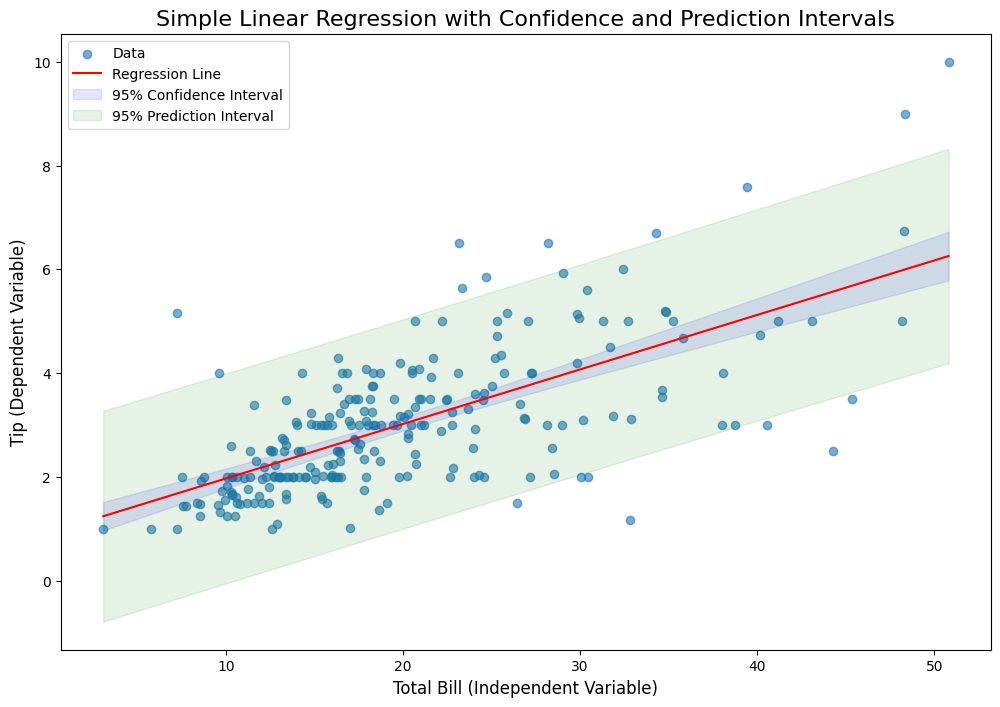

In [22]:
# 예측에 사용할 새로운 X값들 (그래프를 부드럽게 그리기 위함)
X_new = np.linspace(tips['total_bill'].min(), tips['total_bill'].max(), 100)
X_new_sm = sm.add_constant(X_new)

# 예측 결과 및 구간 계산
# 'results' 대신 'model' 사용 (tips 데이터셋의 선형 회귀 모델)
pred = model.get_prediction(X_new_sm)
pred_summary = pred.summary_frame(alpha=0.05)

# 시각화
plt.figure(figsize=(12, 8))

# 원본 데이터 산점도
plt.scatter(tips['total_bill'], y, label='Data', alpha=0.6)

# 회귀선
plt.plot(X_new, pred_summary['mean'], color='red', label='Regression Line')

# 95% 신뢰구간 (Confidence Interval)
plt.fill_between(
    X_new,
    pred_summary['mean_ci_lower'],
    pred_summary['mean_ci_upper'],
    color='blue',
    alpha=0.1,
    label='95% Confidence Interval'
)

# 95% 예측구간 (Prediction Interval)
plt.fill_between(
    X_new,
    pred_summary['obs_ci_lower'],
    pred_summary['obs_ci_upper'],
    color='green',
    alpha=0.1,
    label='95% Prediction Interval'
)

plt.title('Simple Linear Regression with Confidence and Prediction Intervals', fontsize=16)
plt.xlabel('Total Bill (Independent Variable)', fontsize=12)
plt.ylabel('Tip (Dependent Variable)', fontsize=12)
plt.legend()
plt.savefig('linear_regression_intervals.png')
plt.show()

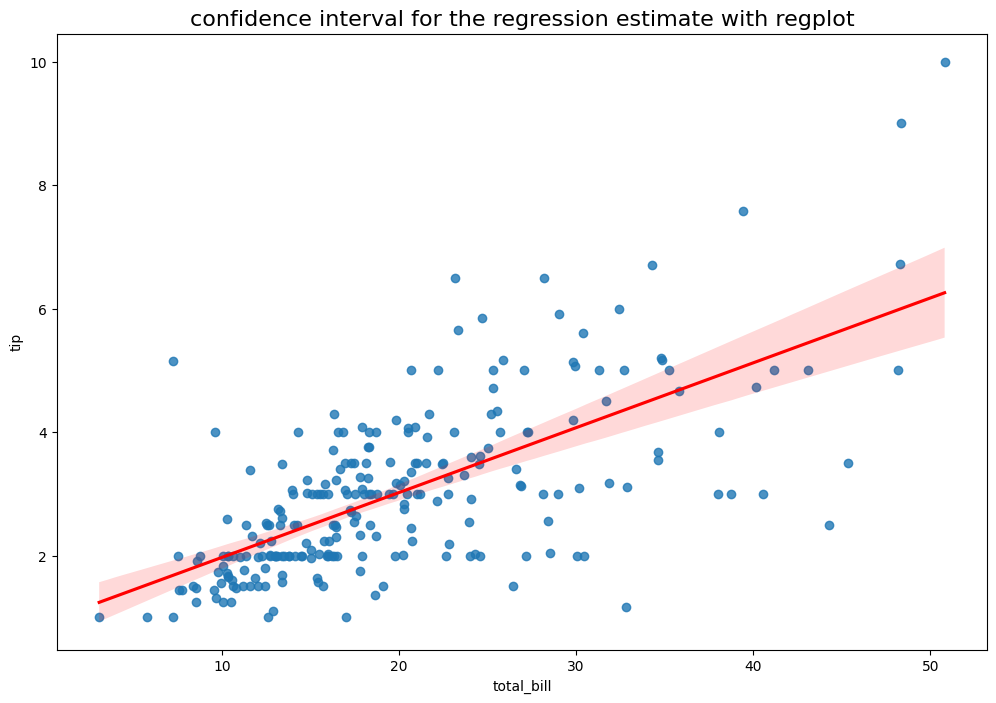

In [23]:
# seaborn의 regplot을 사용하면 회귀직선의 (부트스트랩을 통한) 신뢰구간을 간단하게 표현할 수 있습니다

plt.figure(figsize=(12, 8))

sns.regplot(x=tips['total_bill'], y=y, line_kws={'color':'red'})
plt.title('confidence interval for the regression estimate with regplot', fontsize=16)

plt.show()

**결정계수**

In [24]:
# scikit-leanr을 활용한 결정계수 구하기
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 'total_bill' 컬럼을 2D 배열로 재구성
X_reshaped = tips['total_bill'].values.reshape(-1, 1)

sklearn_model = LinearRegression()
sklearn_model.fit(X_reshaped, y)

y_pred = sklearn_model.predict(X_reshaped)

print(f"sklearn.score: {sklearn_model.score(X_reshaped, y):.4f}")
print(f"r2_score: {r2_score(y, y_pred):.4f}")

sklearn.score: 0.4566
r2_score: 0.4566


In [25]:
# 결정계수 비교하기

# 데이터 생성

np.random.seed(42)
# 1. 결정계수가 높은 경우의 데이터 생성
X_high = np.arange(1, 101).reshape(-1, 1)
# y = 2x + 5 의 관계를 가지지만, 약간의 노이즈 추가
y_high = 2 * X_high.flatten() + 5 + np.random.normal(0, 15, 100)

# 2. 결정계수가 낮은 경우의 데이터 생성
X_low = np.arange(1, 101).reshape(-1, 1)
# 뚜렷한 관계가 없도록 노이즈를 크게 추가
y_low = 0.5 * X_low.flatten() + 10 + np.random.normal(0, 50, 100)

**단순선형회귀: 폐활량과 먼지노출**
- 단순선형회귀: 먼지노출정도(Exposure) 에 따른 폐활량(PEFR)

In [26]:
# GitHub의 파일 경로
url = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/LungDisease.csv"
# CSV 파일 불러오기
lung = pd.read_csv(url)
# 데이터 확인
lung.head(3)

,PEFR,Exposure
0,390,0
1,410,0
2,430,0


In [27]:
# 회귀모형 생성
X = sm.add_constant(lung['Exposure'])  # 상수항 추가
y = lung['PEFR']
model = sm.OLS(y, X).fit()
# 잔차 및 예측값
residuals = model.resid
fitted_values = model.fittedvalues

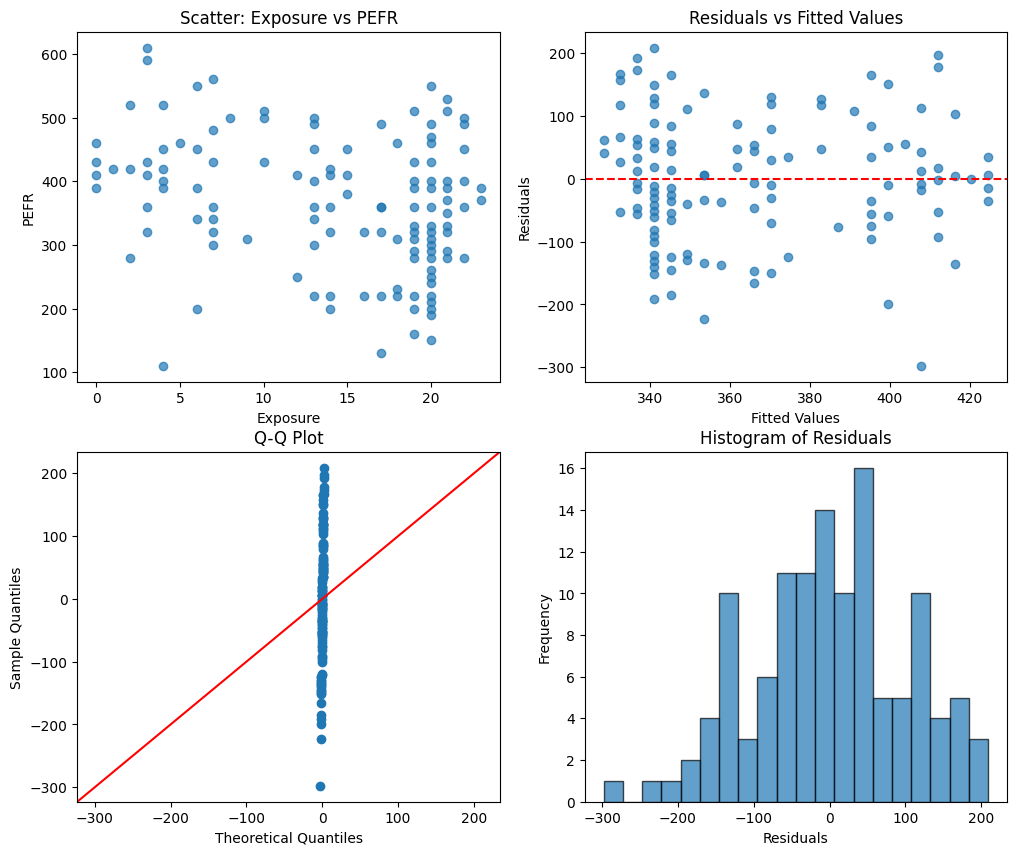

In [28]:
# 2x2 subplot 생성
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

# 1. 선형성: 산점도: Exposure vs PEFR
ax[0, 0].scatter(lung['Exposure'], lung['PEFR'], alpha=0.7)
ax[0, 0].set_title('Scatter: Exposure vs PEFR')
ax[0, 0].set_xlabel('Exposure')
ax[0, 0].set_ylabel('PEFR')

# 2. 잔차 vs 예측값 (등분산성)
ax[0, 1].scatter(fitted_values, residuals, alpha=0.7)
ax[0, 1].axhline(y=0, linestyle='--', color='red')
ax[0, 1].set_title('Residuals vs Fitted Values')
ax[0, 1].set_xlabel('Fitted Values')
ax[0, 1].set_ylabel('Residuals')

# 3. Q-Q Plot (정규성 검토)
sm.qqplot(residuals, line='45', ax=ax[1, 0])
ax[1, 0].set_title('Q-Q Plot')

# 4. 잔차의 히스토그램
ax[1, 1].hist(residuals, bins=20, alpha=0.7, edgecolor='black')
ax[1, 1].set_title('Histogram of Residuals')
ax[1, 1].set_xlabel('Residuals')
ax[1, 1].set_ylabel('Frequency')

plt.show()

In [29]:
# 선형관계: 상관관계
print('1. 선형성: 상관관계')
display(lung[['PEFR', 'Exposure']].corr().round(2))

# 더빈왓슨 통계: 오차의 자기 상관
dw_stat = durbin_watson(residuals)
print(f'2. 더빈왓슨 오차의 자기 상관: {dw_stat:.3f}')

# 잔차의 정규성 확인
shapiro_stat, shapiro_p_value = shapiro(residuals)
print(f"3. 정규성 샤피로 윌크 \n통계량: {shapiro_stat:.3f}, p-value: {shapiro_p_value:.3f}")

#

1. 선형성: 상관관계


,PEFR,Exposure
PEFR,1.00,-0.28
Exposure,-0.28,1.00


2. 더빈왓슨 오차의 자기 상관: 1.111
3. 정규성 샤피로 윌크 
통계량: 0.991, p-value: 0.586


In [30]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   PEFR   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     9.974
Date:                Sat, 04 Apr 2026   Prob (F-statistic):            0.00201
Time:                        14:10:49   Log-Likelihood:                -735.68
No. Observations:                 122   AIC:                             1475.
Df Residuals:                     120   BIC:                             1481.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        424.5828     20.796     20.417      0.000     383.408     465.757
Exposure      -4.1846      1.325     -3.158      0.002      -6.808      -1.561
==============================================================================
Omnibus:                        0.767   Durbin-Watson:                   1.111
Prob(Omnibus):                  0.681   Jarque-Bera (JB):                0.891
Skew:                          -0.162   Prob(JB):                        0.641
Kurtosis:                       2.734   Cond. No.                         35.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# 다중선형회귀

**2-1 마케팅 매출 예측**
- date: 날짜 (주 단위)
- ad_spend: 광고비 (단위: 백만 원)
- discount_rate: 할인율 (단위: %)
- store_visits: 매장 방문 수 (단위: 천 명)
- season: 계절성 변수 (1: 봄, 2: 여름, 3: 가을, 4: 겨울)
- sales: 매출 (단위: 백만 원)

,date,ad_spend,discount_rate,store_visits,season,sales
date,1.00,-0.13,0.06,0.10,-0.07,-0.11
ad_spend,-0.13,1.00,-0.16,0.01,0.04,0.96
discount_rate,0.06,-0.16,1.00,0.02,0.14,-0.27
store_visits,0.10,0.01,0.02,1.00,0.14,0.09
season,-0.07,0.04,0.14,0.14,1.00,0.04
sales,-0.11,0.96,-0.27,0.09,0.04,1.00


Mean Squared Error (MSE): 93.43
R-squared (R²): 0.92


,Feature,Coefficient
0,ad_spend,1.551682
1,discount_rate,-0.779079
2,store_visits,0.042387
3,season,0.860413


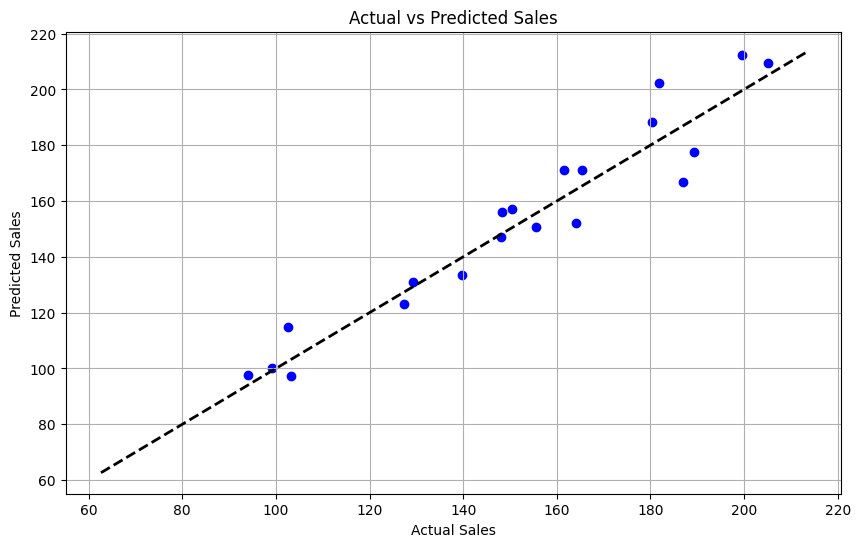

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm

# 랜덤 시드 고정
np.random.seed(42)

# 가상 데이터 생성
n = 100  # 데이터 개수
dates = pd.date_range(start="2023-01-01", periods=n, freq='W')

# 독립 변수 생성
ad_spend = np.random.randint(20, 100, size=n)    # 광고비 (단위: 백만 원)
discount_rate = np.random.uniform(5, 30, size=n)  # 할인율 (단위: %)
store_visits = np.random.randint(200, 500, size=n) # 매장 방문 수 (단위: 천 명)
season = np.random.choice([1, 2, 3, 4], size=n)    # 계절성 (봄, 여름, 가을, 겨울)

# 종속 변수 (매출) 생성 - 광고비, 할인율, 매장 방문 수, 계절성 요인 활용
sales = (
    50 + 1.5 * ad_spend
    - 0.8 * discount_rate
    + 0.05 * store_visits
    + np.random.normal(0, 10, size=n)
)

# 데이터프레임 생성
df = pd.DataFrame({
    'date': dates,
    'ad_spend': ad_spend,
    'discount_rate': discount_rate,
    'store_visits': store_visits,
    'season': season,
    'sales': sales
})

display(df.corr().round(2))

# 특성 및 타겟 변수 설정
X = df[['ad_spend', 'discount_rate', 'store_visits', 'season']]
y = df['sales']

# 데이터 분할 (80% 학습, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 회귀 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측 수행
y_pred = model.predict(X_test)

# 모델 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

# 회귀 계수 출력
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

display(coefficients)

# 예측 결과 시각화
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.grid(True)
plt.show()

- 해석
    - ad_spend: 광고비가 증가할수록 매출이 증가 (𝛽>0)
    - discount_rate: 할인율이 높아질수록 매출이 감소 (𝛽<0)
    - store_visits: 매장 방문 수가 많을수록 매출이 증가 (𝛽>0)
    - season: 계절에 따른 매출 변화도 분석 가능

- 가정 검정

                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.944
Method:                 Least Squares   F-statistic:                     417.4
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           2.44e-59
Time:                        14:10:49   Log-Likelihood:                -363.30
No. Observations:                 100   AIC:                             736.6
Df Residuals:                      95   BIC:                             749.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            50.7221      5.472      9.269

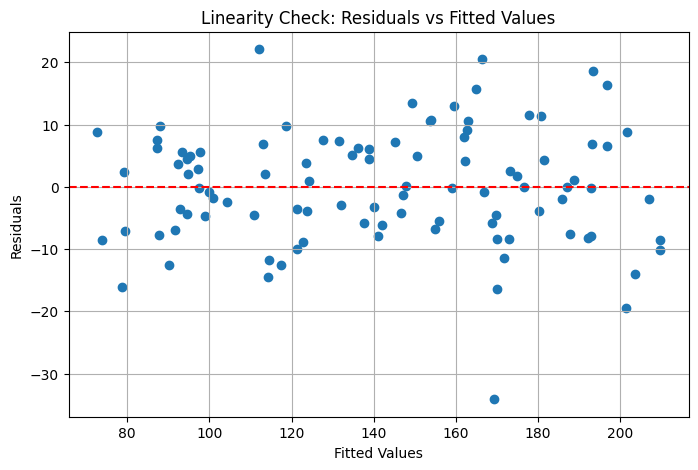

Durbin-Watson Statistic: 2.31 (2에 가까울수록 독립성 만족)


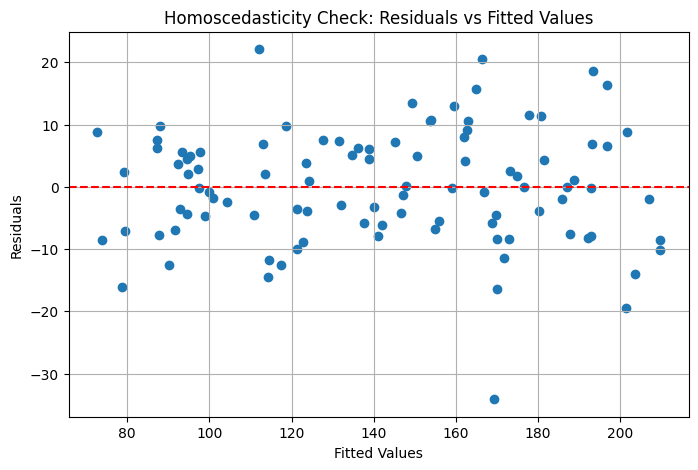

Breusch-Pagan Test p-value: 0.1484 (p < 0.05이면 등분산성 위반)


<Figure size 800x500 with 0 Axes>

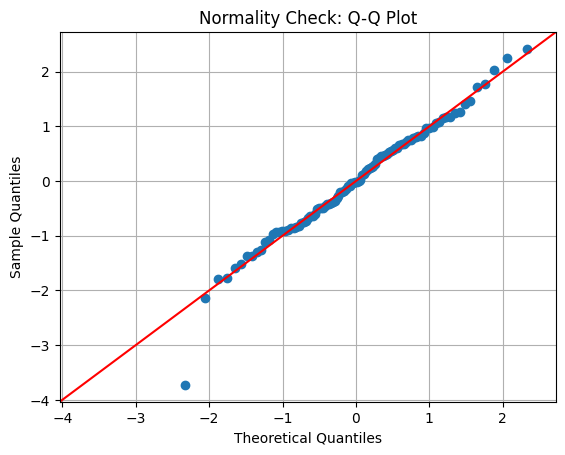

Shapiro-Wilk Test p-value: 0.2906 (p < 0.05이면 정규성 위반)
Jarque-Bera Test p-value: 0.0705 (p < 0.05이면 정규성 위반)


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro, jarque_bera

# 데이터프레임 df는 앞서 생성된 가상 매출 예측 데이터 사용
np.random.seed(42)

# 특성 및 타겟 변수 설정
X = df[['ad_spend', 'discount_rate', 'store_visits', 'season']]
X = sm.add_constant(X)  # 상수항 추가
y = df['sales']

# 회귀 모델 학습 (statsmodels 사용)
model = sm.OLS(y, X).fit()
print(model.summary())

# 잔차 계산
residuals = model.resid
fitted_values = model.fittedvalues

# 1. 선형성(Linearity) 확인: 예측된 값과 잔차의 산점도
plt.figure(figsize=(8, 5))
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Linearity Check: Residuals vs Fitted Values')
plt.grid(True)
plt.show()

# 2. 독립성(Independence) 확인: 잔차의 자기상관 검정 (Durbin-Watson)
dw_stat = sm.stats.stattools.durbin_watson(residuals)
print(f'Durbin-Watson Statistic: {dw_stat:.2f} (2에 가까울수록 독립성 만족)')

# 3. 등분산성(Homoscedasticity) 확인: 잔차의 분산이 일정한지 검토
plt.figure(figsize=(8, 5))
plt.scatter(fitted_values, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Homoscedasticity Check: Residuals vs Fitted Values')
plt.grid(True)
plt.show()

# 등분산성 검정: Breusch-Pagan Test
bp_test = sm.stats.diagnostic.het_breuschpagan(residuals, X)
print(f'Breusch-Pagan Test p-value: {bp_test[1]:.4f} (p < 0.05이면 등분산성 위반)')

# 4. 정규성(Normality) 확인: 잔차의 Q-Q 플롯
plt.figure(figsize=(8, 5))
sm.qqplot(residuals, line='45', fit=True)
plt.title('Normality Check: Q-Q Plot')
plt.grid(True)
plt.show()

# 정규성 검정: Shapiro-Wilk Test 및 Jarque-Bera Test
shapiro_test = shapiro(residuals)
jarque_bera_test = jarque_bera(residuals)
print(f'Shapiro-Wilk Test p-value: {shapiro_test.pvalue:.4f} (p < 0.05이면 정규성 위반)')
print(f'Jarque-Bera Test p-value: {jarque_bera_test.pvalue:.4f} (p < 0.05이면 정규성 위반)')

In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF 계산
vif = pd.DataFrame()
vif["features"] = X.columns
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif = vif.sort_values(by = 'VIF Factor', ascending = False)

display(vif.round(2))

,features,VIF Factor
0,const,33.96
2,discount_rate,1.05
4,season,1.04
1,ad_spend,1.03
3,store_visits,1.02


- 설명
    - 선형성 확인:
        예측 값과 잔차 간의 산점도에서 패턴이 없고, 잔차들이 무작위로 분포하면 선형성 가정이 만족됨.
    - 독립성 확인 (Durbin-Watson 검정):
    Durbin-Watson 통계량이 2에 가까울수록 잔차의 독립성이 만족됨.
    값이 0에 가까우면 양의 자기상관, 4에 가까우면 음의 자기상관이 있음.

    - 등분산성 확인 (Breusch-Pagan 검정):
    예측 값과 잔차의 산점도에서 잔차의 분산이 일정하면 등분산성이 만족됨.
    Breusch-Pagan 테스트의 p-value가 0.05 이상이면 등분산성을 만족한다고 볼 수 있음.

    - 정규성 확인 (Q-Q Plot 및 정규성 테스트):
    Q-Q 플롯에서 잔차들이 대각선에 가까울수록 정규성 가정이 만족됨.
    Shapiro-Wilk 및 Jarque-Bera 테스트의 p-value가 0.05 이상이면 정규성을 만족한다고 볼 수 있음.

- 분석 결과 해석
    - Durbin-Watson 값: 2에 가까울수록 독립성 가정이 만족됨.
    - Breusch-Pagan Test p-value: 0.05 이상이면 등분산성 가정이 만족됨.
    - Shapiro-Wilk Test p-value: 0.05 이상이면 정규성 가정이 만족됨.

**킹 카운티 주택 정보**

In [34]:
import pandas as pd

# GitHub의 파일 경로
url = "https://raw.githubusercontent.com/gedeck/practical-statistics-for-data-scientists/master/data/house_sales.csv"
# CSV 파일 불러오기
house = pd.read_csv(url, sep = '\t')
# 데이터 확인
house.head(3)

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False


In [35]:
house.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22687 entries, 1 to 27063
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   DocumentDate     22687 non-null  object 
 1   SalePrice        22687 non-null  int64  
 2   PropertyID       22687 non-null  int64  
 3   PropertyType     22687 non-null  object 
 4   ym               22687 non-null  object 
 5   zhvi_px          22687 non-null  int64  
 6   zhvi_idx         22687 non-null  float64
 7   AdjSalePrice     22687 non-null  float64
 8   NbrLivingUnits   22687 non-null  int64  
 9   SqFtLot          22687 non-null  int64  
 10  SqFtTotLiving    22687 non-null  int64  
 11  SqFtFinBasement  22687 non-null  int64  
 12  Bathrooms        22687 non-null  float64
 13  Bedrooms         22687 non-null  int64  
 14  BldgGrade        22687 non-null  int64  
 15  YrBuilt          22687 non-null  int64  
 16  YrRenovated      22687 non-null  int64  
 17  TrafficNoise     

In [36]:
subset = ['AdjSalePrice', 'SqFtTotLiving','SqFtLot','Bathrooms','Bedrooms','BldgGrade']
house[subset].head(3)

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
1,300805.0,2400,9373,3.00,6,7
2,1076162.0,3764,20156,3.75,4,10
3,761805.0,2060,26036,1.75,4,8


In [37]:
import statsmodels.api as sm
X = house[['SqFtLot','Bedrooms']]
y = house['AdjSalePrice']

In [38]:
model = sm.OLS(y,X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:           AdjSalePrice   R-squared (uncentered):                   0.716
Model:                            OLS   Adj. R-squared (uncentered):              0.716
Method:                 Least Squares   F-statistic:                          2.860e+04
Date:                Sat, 04 Apr 2026   Prob (F-statistic):                        0.00
Time:                        14:10:49   Log-Likelihood:                     -3.2273e+05
No. Observations:               22687   AIC:                                  6.455e+05
Df Residuals:                   22685   BIC:                                  6.455e+05
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [39]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_vif = X
vif = pd.DataFrame()
vif['VIF Factor'] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]
# display(vif)
vif['Feature'] = df_vif.columns
vif = vif.sort_values(by = 'VIF Factor', ascending = False)
display(vif.round(2))

,VIF Factor,Feature
0,1.17,SqFtLot
1,1.17,Bedrooms


In [40]:
res = pd.merge(house[subset], pd.DataFrame(model.fittedvalues), left_index = True, right_index = True)
res.head(3)

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,0
1,300805.0,2400,9373,3.00,6,7,975509.060207
2,1076162.0,3764,20156,3.75,4,10,672321.717173
3,761805.0,2060,26036,1.75,4,8,681615.819634


In [41]:
res.columns

Index([ 'AdjSalePrice', 'SqFtTotLiving',       'SqFtLot',     'Bathrooms',
            'Bedrooms',     'BldgGrade',               0],
      dtype='object')

In [42]:
from sklearn.metrics import mean_squared_error

mean_squared_error(res['AdjSalePrice'], res[0])

132893509355.78694

**Best case use(sklearn예시)**

In [43]:
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms',
          'Bedrooms', 'BldgGrade']
house[subset].head()

,AdjSalePrice,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade
1,300805.0,2400,9373,3.00,6,7
2,1076162.0,3764,20156,3.75,4,10
3,761805.0,2060,26036,1.75,4,8
4,442065.0,3200,8618,3.75,5,7
5,297065.0,1720,8620,1.75,4,7


In [44]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms',
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])

print(f'Intercept: {house_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(predictors, house_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -521871.368
Coefficients:
 SqFtTotLiving: 228.83060360240498
 SqFtLot: -0.06046682065305298
 Bathrooms: -19442.8403983214
 Bedrooms: -47769.955185213956
 BldgGrade: 106106.96307898125


In [45]:
fitted = house_lm.predict(house[predictors])
RMSE = np.sqrt(mean_squared_error(house[outcome], fitted))
r2 = r2_score(house[outcome], fitted)
print(f'RMSE: {RMSE:.0f}')
print(f'r2: {r2:.4f}')

RMSE: 261220
r2: 0.5406


In [46]:
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.111
Method:                 Least Squares   F-statistic:                     1413.
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:10:50   Log-Likelihood:            -3.2266e+05
No. Observations:               22687   AIC:                         6.453e+05
Df Residuals:                   22684   BIC:                         6.453e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.108e+05   9310.630     11.895      0.0

In [47]:
model = sm.OLS(house[outcome], house[predictors].assign(const=1))
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:10:50   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   228.8306      3.899     58.694

- 모델 선택

In [48]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated',
              'NewConstruction']

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)
X['NewConstruction'] = [1 if nc else 0 for nc in X['NewConstruction']]

house_full = sm.OLS(house[outcome], X.assign(const=1))
results = house_full.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     2771.
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:10:50   Log-Likelihood:            -3.1375e+05
No. Observations:               22687   AIC:                         6.275e+05
Df Residuals:                   22674   BIC:                         6.276e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
SqFtTotLiving       

# 로지스틱 회귀

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
# 데이터 생성
data = {'study_hours': [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10],
        'passed':      [0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
df = pd.DataFrame(data)

In [51]:
X = df[['study_hours']]
y = df['passed']

model = LogisticRegression()
model.fit(X, y)

print(f"회귀계수 (Coefficient): {model.coef_[0][0]:.4f}")
print(f"절편 (Intercept): {model.intercept_[0]:.4f}\n")

회귀계수 (Coefficient): 1.3329
절편 (Intercept): -6.3269



/Users/chankyulee/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


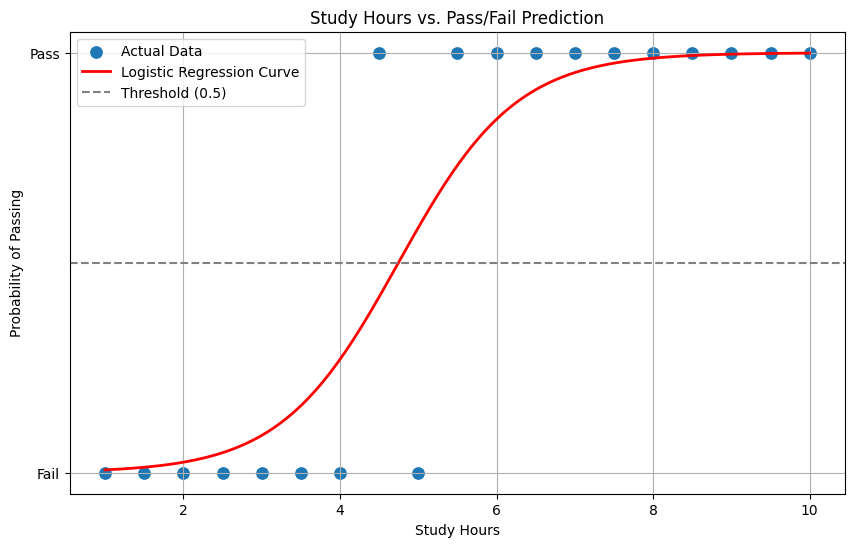

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='study_hours', y='passed', data=df, s=100, label='Actual Data')

x_values = np.linspace(df['study_hours'].min(), df['study_hours'].max(), 300).reshape(-1, 1)
y_probs = model.predict_proba(x_values)[:, 1]

plt.plot(x_values, y_probs, color='red', linewidth=2, label='Logistic Regression Curve')
plt.axhline(y=0.5, color='grey', linestyle='--', label='Threshold (0.5)') # 결정 경계
plt.title('Study Hours vs. Pass/Fail Prediction')
plt.xlabel('Study Hours')
plt.ylabel('Probability of Passing')
plt.yticks([0, 1], ['Fail', 'Pass'])
plt.legend()
plt.grid(True)
plt.show()

**로지스틱 회귀 함수의 해석**

In [53]:
import statsmodels.api as sm
import numpy as np

In [54]:
# 데이터 생성
#  특정 학생이 공부한 시간(hours)을 바탕으로 시험 합격 여부(pass)를 예측하는 가상의 데이터
data = {
    'hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'pass': [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]  # 0: 불합격, 1: 합격
}
df = pd.DataFrame(data)

X = df[['hours']]  # 독립 변수 (공부 시간)
y = df['pass'] # 종속 변수 (합격 여부)

In [55]:
# 로지스틱 회귀 모델 학습 (Logit 사용)
logit_model = sm.Logit(y, X)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.515951
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                   pass   No. Observations:                   10
Model:                          Logit   Df Residuals:                        9
Method:                           MLE   Df Model:                            0
Date:                Sat, 04 Apr 2026   Pseudo R-squ.:                  0.2334
Time:                        14:10:50   Log-Likelihood:                -5.1595
converged:                       True   LL-Null:                       -6.7301
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
hours          0.2289      0.145      1.582      0.114      -0.055       0.512


In [56]:
# 오즈비 계산 및 해석
# 회귀계수(coef)에 자연상수(exp)를 취해 오즈비를 계산합니다.
odds_ratios = pd.DataFrame(
    {
        'Odds Ratio': np.exp(result.params),
        'p-value': result.pvalues,
    }
)

odds_ratios

,Odds Ratio,p-value
hours,1.257262,0.113559


오즈비가 1.26. 공부 시간이 1시간 늘어날 때마다 시험에 합격할 오즈가 1.26배 증가함을 의미

# 문제 1 : 관계를 숫자로 요약하기, 상관계수

**🎯 목표:** 눈으로 확인한 관계의 **방향**과 **강도**를 **상관계수**라는 하나의 숫자로 계산하고, 그 숫자의 의미를 해석하는 방법을 배웁니다.


**핵심 개념:**

**피어슨 상관계수(r)** 는 두 변수가 얼마나 '똑바로', '함께' 움직이는지를 -1에서 +1 사이의 점수로 알려줍니다.

- **부호(+, -):** 관계의 **방향**을 의미합니다.
  - `+` (양수): 한 변수가 커질 때 다른 변수도 같이 커지는 **양의 상관관계** (예: 공부 시간과 성적).
  - `-` (음수): 한 변수가 커질 때 다른 변수는 작아지는 **음의 상관관계** (예: 운동 시간과 체지방률).
- **크기(절대값):** 관계의 **강도**를 의미합니다.
  - `1` 또는 `-1`에 가까울수록 점들이 거의 일직선 위에 놓인 강한 관계입니다.
  - `0`에 가까울수록 관계가 없거나, 직선이 아닌 다른 복잡한 관계(비선형 관계)일 수 있습니다.


**코드 작성:**


In [57]:
# 1. 분석할 두 변수를 선택하고, 빈칸(결측치)이 있는 행을 제거하세요.
df_corr = penguins[['bill_length_mm', 'bill_depth_mm']].dropna()

# 2. 여기에 상관계수를 계산하는 코드를 작성하세요.
# 위에서 만든 df_corr 데이터프레임에 .corr() 메소드를 적용합니다.
correlation_matrix = df_corr.corr()

# 계산된 상관계수 행렬을 출력합니다.
print(correlation_matrix)

# 3. 결과 해석
# 상관계수 값: -0.235
# 상관계수가 음수(-)이므로 두 변수는 음의 관계(하나가 커지면 다른 하나는 작아지는 경향)를 가집니다. 
# 하지만 값의 절대값이 0.235로 0에 가까우므로, 그 관계는 매우 약한 선형 관계라고 할 수 있습니다.

                bill_length_mm  bill_depth_mm
bill_length_mm        1.000000      -0.235053
bill_depth_mm        -0.235053       1.000000


**🤔 생각해 볼 문제:**

두 변수의 상관계수가 -0.23으로 계산되었습니다. 이 사실이 '부리 길이가 길어지는 것이 부리 두께를 얇아지게 하는 원인이다'라는 것을 증명하나요? '상관관계는 인과관계가 아니다'라는, 데이터 분석에서 가장 중요한 원칙 중 하나를 이 예시로 설명해 봅시다.


<details>
<summary><strong>🧑‍🏫 해설 보기</strong></summary>

상관계수가 -0.23이라는 사실은 '부리 길이'와 '부리 두께' 사이에 약한 음의 선형 관계가 관찰된다는 **통계적 현상**을 말해줄 뿐, 둘 사이에 **인과관계**가 있다는 것을 증명하지는 않습니다.

'상관관계는 인과관계가 아니다'라는 원칙을 이 예시로 다음과 같이 설명할 수 있습니다.

1.  **숨어있는 제3의 변수(잠재 변수) 가능성:** 부리 길이와 두께를 모두 결정하는 근본적인 원인은 '펭귄의 종(species)'이나 '유전적 특성'일 수 있습니다. 예를 들어, Gentoo 펭귄은 유전적으로 부리가 길고 두꺼운 경향이 있고, Adelie 펭귄은 부리가 짧고 얇은 경향이 있을 수 있습니다. 이처럼 두 변수는 공통의 원인 때문에 함께 움직이는 것처럼 보일 수 있으며, 부리 길이 자체가 부리 두께의 원인이 되는 것은 아닙니다.
2.  **역인과관계 가능성:** 부리 두께가 부리 길이에 영향을 줄 수도 있으며, 어느 쪽이 원인이고 결과인지 단정할 수 없습니다.
3.  **우연의 일치:** 매우 약한 상관관계는 우연히 나타난 패턴일 수도 있습니다.

따라서 "부리 길이가 길수록 부리 두께가 얇아지는 경향이 관찰되었다"라고 말할 수는 있지만, "부리 길이가 길어졌기 때문에 부리 두께가 얇아졌다"라고 결론 내리는 것은 논리적 비약이며 매우 위험한 해석입니다.


---


# 문제 2 : 관계를 대표하는 공식 만들기, 선형 회귀

**🎯 목표:** 두 변수의 관계를 가장 잘 나타내는 하나의 직선(회귀선)을 찾고, 그 직선을 `y = a + bx` 형태의 **회귀식**으로 표현하는 방법을 학습합니다.


**💡 핵심 개념:**

**선형 회귀분석**은 흩어진 점들 사이를 가장 잘 가로지르는 '최적의 직선'을 찾는 과정입니다. 이 직선을 통해 한 변수(독립변수, x)의 값을 알 때 다른 변수(종속변수, y)의 값을 예측할 수 있습니다.

- **종속변수 (y, 반응변수):** 우리가 예측하고 싶은 대상 (예: 몸무게)
- **독립변수 (x, 설명변수):** 예측의 근거가 되는 변수 (예: 날개 길이)
- **회귀식 (`y = a + bx`):**
  - `a` (절편, Intercept): 독립변수 x가 0일 때의 y 예측값. 직선이 y축과 만나는 지점입니다.
  - `b` (기울기, Coefficient): 독립변수 x가 1만큼 증가할 때 y가 얼마나 변하는지를 나타냅니다. 관계의 핵심적인 효과를 보여줍니다.


📌 수행 과제:

1. `statsmodels` 라이브러리의 `ols` 함수를 사용하여 **'날개 길이(`flipper_length_mm`)'로 '몸무게(`body_mass_g`)'를 예측**하는 회귀 모델을 만드세요.
2. 학습된 모델의 `.summary()` 메소드를 호출하여 분석 결과표를 출력하세요.
3. 결과표의 `coef` 열에서 **절편(Intercept)**과 **기울기(flipper_length_mm)** 값을 찾아 회귀식을 완성해 보세요.


**코드 작성:**


In [58]:
# 모델 학습 전, 사용할 변수들에 빈칸이 있는 행들을 제거합니다.
penguins_cleaned = penguins.dropna(subset=['body_mass_g', 'flipper_length_mm'])

# 1. 여기에 OLS 회귀 모델을 학습시키는 코드를 작성하세요.
# smf.ols() 함수를 사용하고, formula는 '종속변수 ~ 독립변수' 형태로 작성합니다.
model = smf.ols(formula='body_mass_g ~ flipper_length_mm', data=penguins_cleaned).fit()

# 2. 여기에 모델의 요약 결과표를 출력하는 코드를 작성하세요.
print(model.summary())
# 3. 결과 해석 (아래 주석에 직접 작성해 보세요)
# 절편(a) 값: -5780.8314
# 기울기(b) 값: 49.6856
# 완성된 회귀식 (몸무게 = a + b * 날개길이): 몸무게(g) = -5780.8314 + 49.6856 * 날개길이(mm)

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Sat, 04 Apr 2026   Prob (F-statistic):          4.37e-107
Time:                        14:10:50   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5780.8314    305.81

**🤔 생각해 볼 문제:**

회귀식의 기울기(b)는 '날개 길이가 1mm 늘어날 때 몸무게가 평균적으로 얼마나 변하는지'를 나타냅니다. 이 기울기 값을 이용해, 날개 길이가 우리 데이터의 평균보다 10mm 더 긴 펭귄은 평균적인 펭귄보다 몸무게가 약 몇 g 더 무거울 것이라고 구체적인 숫자로 예측해 봅시다.


<details>
<summary><strong>🧑‍🏫 해설 보기</strong></summary>

1.  **기울기(b) 값 확인:** 먼저, 문제 3의 회귀분석 결과표에서 `flipper_length_mm`의 계수(coefficient), 즉 기울기 값을 찾습니다. 이 값은 약 **50.15** 입니다.
2.  **기울기의 의미 해석:** 이 기울기는 '날개 길이가 1mm 늘어날 때마다, 몸무게는 평균적으로 50.15g 증가한다'는 것을 의미합니다.
3.  **예측값 계산:** 따라서 날개 길이가 평균보다 **10mm** 더 길다면, 몸무게는 평균보다 약 **50.15 \* 10 = 501.5g** 더 무거울 것이라고 예측할 수 있습니다.

이처럼 회귀식의 기울기는 두 변수 사이의 관계를 정량적으로 표현해주어, 독립변수의 변화에 따른 종속변수의 변화량을 구체적인 수치로 예측하는 것을 가능하게 합니다.


---


# 문제 3 : 회귀계수의 의미와 통계적 유의성 판단하기

**🎯 목표:** 회귀식의 기울기(b)가 정말로 의미 있는 값인지, 아니면 그냥 우연히 나온 값인지 통계적으로 판단하는 방법을 배웁니다.


**💡 핵심 개념:**

**회귀계수의 가설검정**은 "이 기울기 값이 정말 0이 아니라고 말할 수 있는가?"를 검증하는 과정입니다. 여기서 **p-value(유의확률)**가 핵심적인 역할을 합니다.

- **귀무가설 (H₀):** "두 변수는 관계가 없다. 즉, 기울기는 0이다." (우리가 발견한 관계는 우연이다)
- **대립가설 (H₁):** "두 변수는 관계가 있다. 즉, 기울기는 0이 아니다." (우리가 발견한 관계는 진짜다)
- **p-value:** **귀무가설이 맞다고 가정할 때**, 우리가 현재 데이터에서 관찰한 것과 같거나 더 극단적인 결과가 우연히 나타날 확률입니다.
  - **p-value가 매우 작으면 (보통 0.05 미만):** "이런 일이 우연히 일어날 확률은 매우 낮다. 따라서 귀무가설이 틀렸을 것이다." 라고 판단하고, 두 변수의 관계가 **통계적으로 유의미하다**고 결론 내립니다.


📌 수행 과제:

1. 문제 3에서 출력한 `.summary()` 결과표를 다시 확인합니다.
2. `flipper_length_mm` 행에서 `P>|t|` 열의 값(p-value)을 찾으세요.
3. 이 p-value가 일반적인 유의수준인 0.05보다 작은지 확인하고, 이를 근거로 "펭귄의 날개 길이가 몸무게에 미치는 영향이 통계적으로 유의미한지" 결론을 내리세요.


✍️ 코드 작성:


In [59]:
# 문제 2에서 만든 모델의 summary를 다시 출력하여 p-value를 확인합니다.
print(model.summary())

# 아래 주석에 직접 해석을 작성해보세요.

# 1. flipper_length_mm 계수의 p-value (`P>|t|` 값) 찾기
# 0.000 이 나왔다 -> 0?

# 2. 가설 검정 결과 해석
# p-value가 0.05보다 작은가?: 작다
# 결론 (날개 길이가 몸무게에 미치는 영향은 통계적으로 유의미한가?): 네

                            OLS Regression Results                            
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Sat, 04 Apr 2026   Prob (F-statistic):          4.37e-107
Time:                        14:10:50   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5780.8314    305.81

**🤔 생각해 볼 문제:**

이 분석 결과를 통계에 대해 전혀 모르는 친구에게 설명해야 합니다. "p-value가 0.000이라서 귀무가설을 기각했다"라는 어려운 말 대신, "날개 길이가 몸무게와 정말 관계가 있다"라는 결론을 어떻게 더 쉽고 직관적으로 뒷받침하여 설명할 수 있을까요?


<details>
<summary><strong>🧑‍🏫 해설 보기</strong></summary>

✏️ 예시 답안

통계 용어를 쓰지 않고 친구에게 설명하는 상황을 가정해 봅시다.

"있잖아, 내가 펭귄 데이터를 분석해봤는데, 날개 길이가 길수록 몸무게가 많이 나가는 경향이 뚜렷하게 보이더라고.

근데 이런 생각이 들 수 있잖아. '혹시 그냥 우연 아닐까? 어쩌다 보니 우리가 가진 데이터에서만 그런 관계가 보이는 거 아닐까?'

그래서 그걸 확인해봤어. **만약 날개 길이와 몸무게가 아무 관계가 없다고 가정했을 때, 지금 우리가 본 것처럼 이렇게 강한 관계가 우연히 나타날 확률이 얼마나 될까?** 하고 계산해 본 거야.

결과가 뭔지 알아? 그 확률이 **0.000...%**, 거의 0에 가까웠어. 즉, 이건 '우연이라고 하기에는 너무나 일어나기 힘든 일'이라는 뜻이지.

따라서 '이건 우연이 아닐 거야. 펭귄의 날개 길이는 몸무게와 정말로 의미 있는 관계가 있는 게 맞아'라고 자신 있게 말할 수 있는 거야."


---


# 문제 4 : 상호작용 효과 분석하기

**목표:** 한 변수의 효과가 다른 변수의 상황에 따라 달라지는 **상호작용 효과**를 직접 변수를 곱하여 만들고, 그 의미를 해석합니다.


**핵심 개념:**

**상호작용**은 한 변수의 효과가 다른 변수의 수준에 따라 달라지는 현상을 말합니다. 예를 들어, "식사 금액이 팁에 미치는 영향은 흡연 여부에 따라 다르다"와 같은 가설을 검증할 때 사용됩니다. 배열 방식에서는 상호작용 항을 **두 변수의 곱**으로 직접 만들어서 모델에 추가합니다.


**📌 수행 과제:**

1. "식사 총액(`total_bill`)이 팁에 미치는 영향은 흡연자(`smoker`) 그룹과 비흡연자 그룹에서 다를 것이다"라는 가설을 검증해봅시다.
2. `smoker` 변수를 더미 변수(`smoker_Yes`)로 만드세요. ('Yes' = 1, 'No' = 0)
3. `total_bill`과 `smoker_Yes`를 곱하여 상호작용 항(`bill_x_smoker`)을 만드세요.
4. `total_bill`, `smoker_Yes`, `bill_x_smoker`를 모두 포함하여 회귀 모델을 학습시키고 결과를 해석하세요.


**✍️ 코드 작성:**


In [60]:
# 1. 기본 데이터를 준비합니다.
y = tips['tip']
X = tips[['total_bill']]

# 2. 여기에 'smoker' 더미 변수를 X에 추가하는 코드를 작성하세요.
# 'smoker' 컬럼의 'Yes'를 1, 'No'를 0으로 변환합니다.
# dtype=int를 추가하여 정수형으로 만듭니다.
X['smoker_Yes'] = pd.get_dummies(tips['smoker'], drop_first=True, dtype=int)

# 3. 여기에 상호작용 항을 직접 계산하여 X에 추가하는 코드를 작성하세요.
# 'total_bill' 컬럼과 'smoker_Yes' 컬럼을 곱합니다.
X['bill_x_smoker'] = X['total_bill'] * X['smoker_Yes']

# 4. 상수항을 추가하고 모델을 학습시킨 후 결과를 출력하세요.
X_const = sm.add_constant(X)
model_3 = sm.OLS(y, X_const).fit()
print(model_3.summary())

# 5. 결과 해석
# 상호작용 항(bill_x_smoker)의 p-value는 유의미한가?: p-value(P>|t|)가 0.738로 유의수준 0.05보다 매우 큽니다. 따라서 통계적으로 유의미하지 않습니다. 즉, '식사 금액이 팁에 미치는 영향이 흡연 여부에 따라 다르다'는 가설은 기각됩니다.
# 상호작용 항 계수의 의미: 이 계수(0.0136)는 비흡연자 그룹에 비해 흡연자 그룹에서 total_bill의 기울기가 0.0136만큼 더 크다는 것을 의미합니다. 하지만 p-value가 유의미하지 않으므로 이 차이는 우연에 의한 것일 가능성이 높습니다.

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.506
Model:                            OLS   Adj. R-squared:                  0.500
Method:                 Least Squares   F-statistic:                     81.95
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           1.56e-36
Time:                        14:10:50   Log-Likelihood:                -338.91
No. Observations:                 244   AIC:                             685.8
Df Residuals:                     240   BIC:                             699.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.5643      0.238      6.570

/var/folders/92/1z5rtryn4tdg88w4gm0bv9yw0000gn/T/ipykernel_86949/470938844.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['smoker_Yes'] = pd.get_dummies(tips['smoker'], drop_first=True, dtype=int)
/var/folders/92/1z5rtryn4tdg88w4gm0bv9yw0000gn/T/ipykernel_86949/470938844.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['bill_x_smoker'] = X['total_bill'] * X['smoker_Yes']


**🤔 생각해 볼 문제:**

위 모델에서 비흡연자(smoker_Yes=0)의 `total_bill` 기울기는 얼마일까요? 그리고 흡연자(smoker_Yes=1)의 `total_bill` 기울기는 얼마일까요? (힌트: 흡연자의 기울기 = 기본 `total_bill` 기울기 + 상호작용 항 기울기)


<details>
<summary><strong>🧑‍🏫 해설 보기</strong></summary>

**✏️ 예시 답안**

상호작용 모델에서 특정 그룹의 기울기를 계산하는 방법은 다음과 같습니다.

1.  **비흡연자 그룹 (smoker_Yes = 0):**

    - 이 그룹에서는 `smoker_Yes`와 `bill_x_smoker` 항이 모두 0이 됩니다.
    - 따라서 `total_bill`이 팁에 미치는 영향은 순수하게 `total_bill`의 계수(coef) 값과 같습니다.
    - **비흡연자 그룹의 기울기** = `total_bill` 계수 = **0.0919**

2.  **흡연자 그룹 (smoker_Yes = 1):**
    - 이 그룹에서는 `smoker_Yes`가 1이므로, `total_bill`의 영향력은 기본 `total_bill`의 기울기와 상호작용 항의 기울기가 더해져서 결정됩니다.
    - **흡연자 그룹의 기울기** = `total_bill` 계수 + `bill_x_smoker` 계수 = 0.0919 + 0.0136 = **0.1055**

**결론:**
이 모델에 따르면, 비흡연자는 식사 금액이 1달러 증가할 때 팁이 약 0.092달러 증가하는 반면, 흡연자는 약 0.106달러 증가하는 경향을 보입니다. 즉, 흡연자 그룹에서 식사 금액이 팁에 미치는 영향이 약간 더 큰 것으로 나타납니다. (다만, 앞서 확인했듯이 이 차이는 통계적으로 유의미하지 않습니다.)


---


# 문제 5 : 로지스틱 회귀분석

**🎯 목표:** 결과가 '예/아니오' 같은 범주형일 때 사용하는 **로지스틱 회귀분석**을 구현하고, 그 결과를 **오즈비(Odds Ratio)** 로 해석하는 방법을 배웁니다.


**핵심 개념:**

**로지스틱 회귀분석**은 결과가 '예/아니오', '성공/실패'처럼 **두 가지 중 하나**일 때 사용하는 분석 방법입니다. 어떤 조건에서 특정 결과가 나타날 **'확률'**을 예측합니다. 회귀 계수는 그대로 해석하기 어렵고, `np.exp(계수)`를 계산한 **오즈비(Odds Ratio)**로 해석해야 합니다. 오즈비가 1보다 크면 확률 증가, 1보다 작으면 확률 감소를 의미합니다.


**📌 수행 과제:**

1. 식사 총액(`total_bill`)과 팁(`tip`) 금액을 보고, 그 고객이 '남성'일 확률을 예측하는 로지스틱 회귀 모델을 만들어봅시다.
2. 종속변수 `y`를 'sex'가 'Male'이면 1, 아니면 0이 되도록 변환하세요.
3. `sm.Logit` 함수를 사용하여 모델을 학습시키고, 결과를 확인하세요.
4. `np.exp()`를 이용해 계수를 오즈비로 변환하고, 그 의미를 해석하세요.


**코드 작성:**


In [61]:
# 1. 여기에 종속변수 y를 0과 1로 변환하는 코드를 작성하세요.
# 'sex'가 'Male'이면 1, 아니면 0
# apply와 lambda 함수를 사용하면 편리합니다.
y = tips['sex'].apply(lambda x: 1 if x == 'Male' else 0)

# 2. 독립변수 X를 준비하고 상수항을 추가하세요.
X = tips[['total_bill', 'tip']]
X_const = sm.add_constant(X)

# 3. 여기에 로지스틱 회귀 모델을 학습시키는 코드를 작성하세요.
# sm.Logit() 함수를 사용합니다. (선형 회귀의 sm.OLS와 구분!)
model_4 = sm.Logit(y, X_const).fit()
print(model_4.summary())

# 4. 여기에 오즈비를 계산하고 출력하는 코드를 작성하세요.
# exp 함수를 사용해 모델의 파라미터(계수)를 오즈비로 변환합니다.
odds_ratios = np.exp(model_4.params)
print("\n--- 오즈비 (Odds Ratios) ---")
print(odds_ratios)

# 5. 결과 해석 (아래 주석에 직접 작성해 보세요)
# total_bill 오즈비의 의미:
# tip 오즈비의 의미:

Optimization terminated successfully.
         Current function value: 0.640304
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                    sex   No. Observations:                  244
Model:                          Logit   Df Residuals:                      241
Method:                           MLE   Df Model:                            2
Date:                Sat, 04 Apr 2026   Pseudo R-squ.:                 0.01705
Time:                        14:10:50   Log-Likelihood:                -156.23
converged:                       True   LL-Null:                       -158.94
Covariance Type:            nonrobust   LLR p-value:                   0.06651
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0979      0.363     -0.270      0.787      -0.808       0.613
total_bill     0.0400      0.

**🤔 생각해 볼 문제:**

`model_4.predict(X_const)` 코드를 실행하면 각 손님에 대해 '남성일 확률'을 예측해줍니다. 이 예측 확률이 가장 높은 상위 5명의 손님 데이터(total_bill, tip)는 어떤 특징을 가지고 있는지 확인해보세요.


<details>
<summary><strong>🧑‍🏫 해설 보기</strong></summary>

**✏️ 예시 답안**

로지스틱 회귀 모델의 `.predict()` 메서드는 각 데이터가 1(여기서는 'Male')일 확률을 0과 1 사이의 값으로 반환합니다. 이 예측 확률을 원래 데이터와 합쳐서 어떤 특징을 가진 손님의 '남성일 확률'이 높게 예측되었는지 확인할 수 있습니다.

모델의 계수(`coef`)를 보면 `total_bill`과 `tip` 모두 양수였습니다. 이는 **식사 금액과 팁이 클수록 남성일 확률이 높다**고 모델이 학습했다는 의미입니다.

아래 코드는 이를 직접 확인하는 과정입니다.

1. 예측 확률을 계산하여 `prediction`이라는 새로운 열에 추가합니다.
2. `prediction` 열을 기준으로 내림차순 정렬하여 확률이 높은 순서대로 봅니다.
3. 상위 5개 데이터를 확인하면, 실제로 `total_bill`과 `tip` 금액이 전체 평균보다 훨씬 높은 손님들임을 알 수 있습니다.


코드셀을 추가하여 실행시켜 보세요.

```
# 예측 확률을 계산합니다.
predictions = model_4.predict(X_const)

# 원래 데이터에 예측 확률을 추가합니다.
tips_pred = tips.copy()
tips_pred['prediction'] = predictions

# 예측 확률이 높은 순으로 정렬하여 상위 5개를 출력합니다.
top5_male_pred = tips_pred.sort_values(by='prediction', ascending=False).head()

print(top5_male_pred[['total_bill', 'tip', 'sex', 'prediction']])
```


